# Module 04 — the calibrated-harmonic baseline: can a model learn the error of scaled-harmonic DFT band positions?

**The training table is a derived dataset matching public computed bands (NASA PAHdb theoretical library v4.00) to public laboratory bands (PAHdb experimental library v3.10); its provenance and its distinctness from the Module 02 and 03 datasets are described in `../PROVENANCE.md`; it is not AI-generated.**

Plan 05 (Δ-probed IR pipeline), Module 04 of the Udacity AI Mastery Capstone. **Problem type: supervised regression.** Target per band: y = ν_lab − ν_scaled, the error of the library's scaled-harmonic position against the laboratory position, in cm⁻¹. A model that predicts y corrects the library; this corrected library is the strongest fair opponent the larger project must beat, so the recipe — features, four models, leave-one-molecule-out evaluation, metrics, no tuning, seed 0 — was fixed in `../RECIPE.md` before this notebook first ran. Dataset: `training_table.csv` (built by `../build_training_table.py`).

Sections: **Load and inspect · Preparation and preprocessing · Model selection and training · Evaluation · Summary**.

## Load and inspect the dataset

In [1]:
from pathlib import Path
import json
import numpy as np, pandas as pd
import sklearn
from sklearn.model_selection import LeaveOneGroupOut, KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
%matplotlib inline
import matplotlib.pyplot as plt
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
DATA = Path("training_table.csv"); FIG = Path("figures"); FIG.mkdir(exist_ok=True)
df = pd.read_csv(DATA, dtype={"uid": str})
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| dataset:", df.shape)
df.head()

scikit-learn 1.9.1 | pandas 3.0.3 | dataset: (2477, 28)


,pair_id,uid,formula,charge,n_c,n_h,has_n,n_solo,n_duo,n_trio,n_quartet,point_group,ladder,lab_doi,species_name,nu_lab_cm,rel_int_lab,nu_scaled_cm,nu_unscaled_cm,scale,scale_region,intensity_km_mol,log10_intensity,rel_int_comp,irrep,family,n_candidates,y_cm
0,1,330,C10H8,0,10,8,0,0,0,0,8,1-AG,R1 naphthalene,10.1021/jp9834816,naphthalene,785.8,1.0000,787.9869,804.560854,0.9794,0,90.8148,1.958157,1.0000,B3U,CH-oop (10.5-15 um; benzene nu11 at 673 included),1,-2.187
1,2,330,C10H8,0,10,8,0,0,0,0,8,1-AG,R1 naphthalene,10.1021/jp9834816,naphthalene,3071.6,0.6667,3076.5572,3205.748880,0.9597,2,59.4327,1.774025,0.6544,B2U,CH-stretch,3,-4.957
2,3,330,C10H8,0,10,8,0,0,0,0,8,1-AG,R1 naphthalene,10.1021/jp9834816,naphthalene,473.7,0.1722,481.8409,491.975597,0.9794,0,12.2288,1.087384,0.1347,B3U,low / skeletal,1,-8.141
3,4,330,C10H8,0,10,8,0,0,0,0,8,1-AG,R1 naphthalene,10.1021/jp9834816,naphthalene,1272.8,0.0722,1256.8352,1296.909710,0.9691,1,7.9748,0.901720,0.0878,B1U,CC-stretch/CH-ip (7.7 um),1,15.965
4,5,330,C10H8,0,10,8,0,0,0,0,8,1-AG,R1 naphthalene,10.1021/jp9834816,naphthalene,1014.4,0.0722,1023.0611,1044.579436,0.9794,0,4.5771,0.660590,0.0504,B2U,ring / CH-ip (9-10.5 um),1,-8.661


In [2]:
print(df.dtypes.to_string()); print()
print("missing values per column:", df.isna().sum()[df.isna().sum() > 0].to_dict() or "none")
print("molecules:", df.uid.nunique(), "| pairs per molecule: min", df.uid.value_counts().min(), "median", int(df.uid.value_counts().median()), "max", df.uid.value_counts().max())
print("target y (cm^-1): mean %.2f, median %.2f, SD %.2f, |y| > 15: %.1f %%" % (df.y_cm.mean(), df.y_cm.median(), df.y_cm.std(), 100 * (df.y_cm.abs() > 15).mean()))
print("pairs whose laboratory band had more than one computed candidate within the window:", int((df.n_candidates > 1).sum()), "of", len(df))

pair_id               int64
uid                     str
formula                 str
charge                int64
n_c                   int64
n_h                   int64
has_n                 int64
n_solo                int64
n_duo                 int64
n_trio                int64
n_quartet             int64
point_group             str
ladder                  str
lab_doi                 str
species_name            str
nu_lab_cm           float64
rel_int_lab         float64
nu_scaled_cm        float64
nu_unscaled_cm      float64
scale               float64
scale_region          int64
intensity_km_mol    float64
log10_intensity     float64
rel_int_comp        float64
irrep                   str
family                  str
n_candidates          int64
y_cm                float64

missing values per column: {'ladder': 2382, 'lab_doi': 628}
molecules: 83 | pairs per molecule: min 3 median 27 max 63
target y (cm^-1): mean 0.55, median 0.68, SD 9.24, |y| > 15: 11.5 %
pairs whose laboratory band 

*Data quality notes.* No missing values: every row is a matched pair with all descriptors from the PAHdb record. Two issues are visible before modelling. First, the target has heavy tails — about one pair in nine has |y| above 15 cm⁻¹, larger than the published order of scaled-DFT-versus-matrix mismatch (typically within 5, worst about 15 cm⁻¹; Hudgins & Sandford, 1998), so some pairs are probably mis-assignments of the fixed join rule rather than true errors. Second, most laboratory bands had several computed candidates within the ±30 cm⁻¹ window; the rule takes the nearest free one, which is a choice the data cannot verify. Both are limitations of the dataset, declared here and kept as they are: the recipe forbids tuning the join after seeing the result.

## Preparation and preprocessing

Features are the RECIPE's: per band the unscaled harmonic frequency, log₁₀ intensity, relative intensity within the molecule, the stored scale-factor region (categorical) and the frequency-range family (categorical); per molecule the carbon and hydrogen counts, charge, a nitrogen flag and the four hydrogen-adjacency counts. No laboratory quantity is a feature. Numeric features are standardised for the ridge model (its penalty is scale-dependent) and passed through unchanged to the tree model (which is scale-invariant); the two categorical columns are one-hot encoded for both. The evaluation groups are the molecules (PAHdb `uid`), so that no molecule appears on both sides of a split.

In [3]:
NUM = ["nu_unscaled_cm", "log10_intensity", "rel_int_comp", "n_c", "n_h", "charge", "has_n", "n_solo", "n_duo", "n_trio", "n_quartet"]
CAT = ["family", "scale_region"]
X = df[NUM + CAT].copy(); X["scale_region"] = X["scale_region"].astype(str)
y = df["y_cm"].to_numpy(); groups = df["uid"].to_numpy()
pre_scaled = ColumnTransformer([("num", StandardScaler(), NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
pre_trees = ColumnTransformer([("num", "passthrough", NUM), ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])
print("feature matrix:", X.shape, "| numeric:", len(NUM), "| categorical:", CAT, "->", int(X.family.nunique() + X.scale_region.nunique()), "one-hot columns")
print("groups (molecules):", len(np.unique(groups)))
X.describe().round(2).T.head(12)

feature matrix: (2477, 13) | numeric: 11 | categorical: ['family', 'scale_region'] -> 10 one-hot columns
groups (molecules): 83


,count,mean,std,min,25%,50%,75%,max
nu_unscaled_cm,2477.0,1244.10,547.00,445.73,855.02,1221.36,1470.88,3261.48
log10_intensity,2477.0,0.95,0.68,0.00,0.42,0.81,1.36,3.84
rel_int_comp,2477.0,0.14,0.22,0.00,0.02,0.05,0.14,1.00
n_c,2477.0,27.61,11.56,10.00,17.00,22.00,40.00,50.00
n_h,2477.0,14.86,4.25,8.00,11.00,13.00,18.00,22.00
charge,2477.0,0.15,0.50,-1.00,0.00,0.00,0.00,1.00
has_n,2477.0,0.28,0.45,0.00,0.00,0.00,1.00,1.00
n_solo,2477.0,1.96,2.18,0.00,0.00,1.00,2.00,8.00
n_duo,2477.0,3.01,3.50,0.00,0.00,2.00,4.00,16.00
n_trio,2477.0,4.01,3.56,0.00,0.00,6.00,6.00,18.00


## Model selection and training

Four models, from the RECIPE, all trained inside a leave-one-molecule-out loop (83 folds: each molecule is predicted by a model that never saw any of its bands):

0. **zero model** — predict y = 0, i.e. the library as served (this is the reference line the project calls line A);
1. **per-family constant** — the training fold's mean error per family (the simplest recalibration of the scale factors);
2. **ridge regression** (α = 1) on the standardised features — a linear model, chosen as the transparent baseline;
3. **gradient-boosted trees** (`HistGradientBoostingRegressor`, library defaults, `random_state=0`) — a non-linear model able to use interactions between size, family and intensity (Friedman, 2001).

No hyper-parameter search is run (tuning budget zero, by the RECIPE). The leave-one-molecule-out split is the grouped cross-validation appropriate when rows are clustered — here, bands within a molecule share that molecule's systematic error (Roberts et al., 2017).

In [4]:
def make_models():
    """Fresh, unfitted model pipelines for one fold (RECIPE §Models; defaults, seed 0)."""
    return {"ridge": make_pipeline(pre_scaled, Ridge(alpha=1.0)),
            "hgb": make_pipeline(pre_trees, HistGradientBoostingRegressor(random_state=0))}

pred = {k: np.zeros(len(df)) for k in ["zero", "family_mean", "ridge", "hgb"]}
logo = LeaveOneGroupOut()
for fold, (tr, te) in enumerate(logo.split(X, y, groups)):
    fam_mean = df.iloc[tr].groupby("family")["y_cm"].mean()
    pred["family_mean"][te] = df.iloc[te]["family"].map(fam_mean).fillna(y[tr].mean()).to_numpy()
    for name, model in make_models().items():
        model.fit(X.iloc[tr], y[tr])                     # training happens here, once per fold and model
        pred[name][te] = model.predict(X.iloc[te])
print("trained %d folds x 2 fitted models (+ 2 analytic models); held-out predictions for every one of %d pairs" % (logo.get_n_splits(groups=groups), len(df)))

trained 83 folds x 2 fitted models (+ 2 analytic models); held-out predictions for every one of 2477 pairs


## Evaluation

Metrics (RECIPE): mean absolute error (MAE, primary — the plan scores per-band |error|), root-mean-square error, R² of the predicted against the actual error, and the share of bands whose corrected position lies within 5 cm⁻¹ of the laboratory band; overall and per family, for all four models side by side.

In [5]:
def metrics(p):
    r = y - p
    return dict(MAE=np.abs(r).mean(), RMSE=np.sqrt((r ** 2).mean()), R2=1 - (r ** 2).sum() / ((y - y.mean()) ** 2).sum(), within_5=(np.abs(r) <= 5).mean())
overall = pd.DataFrame({k: metrics(p) for k, p in pred.items()}).T
print(overall.round(3))
for k, p in pred.items(): df["res_" + k] = y - p
per_family = df.groupby("family")[[f"res_{k}" for k in pred]].agg(lambda s: np.abs(s).mean()).round(2)
per_family.columns = [c.replace("res_", "MAE ") for c in per_family.columns]; per_family["n"] = df.family.value_counts()
print(); print(per_family)
best = overall["MAE"].idxmin(); print(f"\nRECIPE rule (lowest held-out MAE): {best}  ({overall.loc[best, 'MAE']:.3f} vs zero model {overall.loc['zero', 'MAE']:.3f} cm^-1)")

               MAE   RMSE     R2  within_5
zero         6.491  9.258 -0.004     0.570
family_mean  6.425  9.225  0.004     0.572
ridge        6.399  9.206  0.008     0.581
hgb          6.478  9.257 -0.003     0.564

                                                   MAE zero  MAE family_mean  MAE ridge  MAE hgb    n
family                                                                                               
CC-stretch (6.2 um)                                    6.94             6.94       6.95     7.10  300
CC-stretch/CH-ip (7.7 um)                              7.49             7.38       7.39     7.57  655
CH-ip-bend (8.6 um)                                    6.14             5.98       6.02     6.10  367
CH-oop (10.5-15 um; benzene nu11 at 673 included)      6.10             6.07       6.10     5.93  617
CH-stretch                                             5.99             5.90       5.99     6.50  118
low / skeletal                                         3.49           

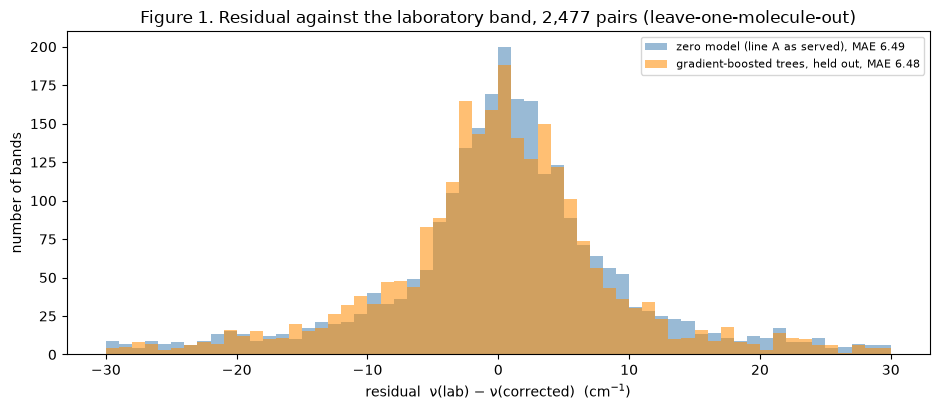

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
bins = np.arange(-30, 30.5, 1.0)
ax.hist(df.res_zero, bins=bins, alpha=0.55, color="steelblue", label=f"zero model (line A as served), MAE {overall.loc['zero','MAE']:.2f}")
ax.hist(df.res_hgb, bins=bins, alpha=0.55, color="darkorange", label=f"gradient-boosted trees, held out, MAE {overall.loc['hgb','MAE']:.2f}")
ax.set_xlabel("residual  ν(lab) − ν(corrected)  (cm$^{-1}$)"); ax.set_ylabel("number of bands")
ax.set_title("Figure 1. Residual against the laboratory band, 2,477 pairs (leave-one-molecule-out)")
ax.legend(fontsize=8); plt.tight_layout(); fig.savefig(FIG / "fig1_residuals.png", dpi=140); plt.show()

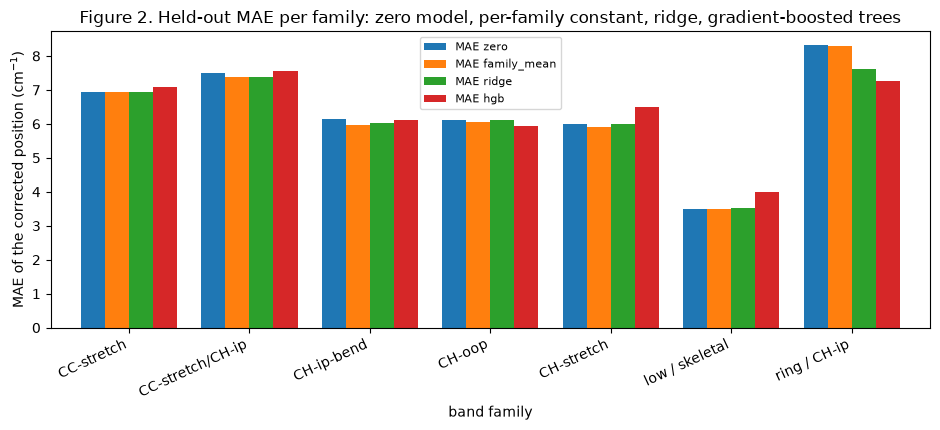

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
pf = per_family.drop(columns="n"); pf.index = [i.split(" (")[0] for i in pf.index]
pf.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("MAE of the corrected position (cm$^{-1}$)"); ax.set_xlabel("band family")
ax.set_title("Figure 2. Held-out MAE per family: zero model, per-family constant, ridge, gradient-boosted trees")
ax.legend(fontsize=8); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); fig.savefig(FIG / "fig2_mae_by_family.png", dpi=140); plt.show()

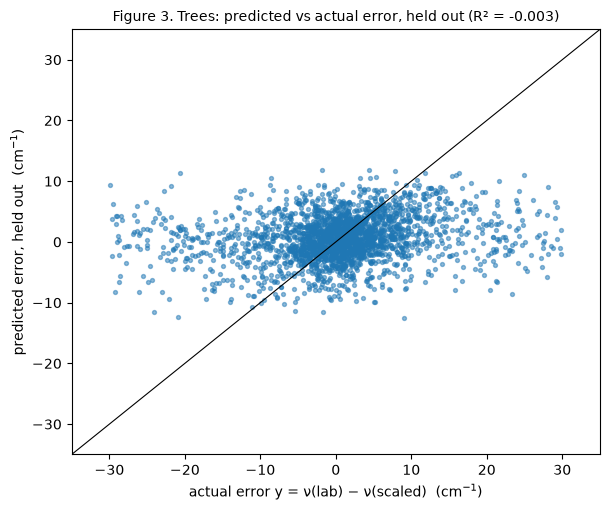

In [8]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.scatter(y, pred["hgb"], s=8, alpha=0.5)
lim = (-35, 35); ax.plot(lim, lim, color="black", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("actual error y = ν(lab) − ν(scaled)  (cm$^{-1}$)"); ax.set_ylabel("predicted error, held out  (cm$^{-1}$)")
ax.set_title(f"Figure 3. Trees: predicted vs actual error, held out (R² = {overall.loc['hgb','R2']:.3f})", fontsize=10)
plt.tight_layout(); fig.savefig(FIG / "fig3_pred_vs_actual.png", dpi=140); plt.show()

*Reading the figures.* Figure 1: the residual distribution of the corrected library is indistinguishable from that of the uncorrected one; both have the same core and the same heavy tails. Figure 2: no model lowers the MAE of any family by more than a fraction of a wavenumber, and in two families the tree model is slightly worse than doing nothing. Figure 3 shows why: the predicted error hardly varies with the actual error — the descriptors carry almost no information about which bands the scaled-harmonic library gets wrong.

In [9]:
# Diagnostics the RECIPE asks for: (a) is the failure a split effect? an instance-level 5-fold split for comparison (not a model choice);
# (b) how much of the error is a per-molecule offset a model could have learned, versus band-to-band scatter within a molecule?
p_inst = np.zeros(len(df))
for tr, te in KFold(5, shuffle=True, random_state=0).split(X):
    m = make_models()["hgb"].fit(X.iloc[tr], y[tr]); p_inst[te] = m.predict(X.iloc[te])
print("gradient-boosted trees, MAE: leave-one-molecule-out %.3f | instance-level 5-fold %.3f | zero model %.3f" % (overall.loc['hgb','MAE'], np.abs(y - p_inst).mean(), overall.loc['zero','MAE']))
mol = df.groupby("uid")["y_cm"].agg(["mean", "std", "count"])
print("SD of the per-molecule mean error: %.2f cm^-1 | mean within-molecule SD: %.2f cm^-1" % (mol["mean"].std(), mol["std"].mean()))
strong = df.rel_int_lab >= 0.1
print("strong laboratory bands (>= 10 %% of the molecule's strongest, n = %d): MAE zero %.2f, trees %.2f" % (strong.sum(), np.abs(y[strong]).mean(), np.abs((y - pred['hgb'])[strong]).mean()))

gradient-boosted trees, MAE: leave-one-molecule-out 6.478 | instance-level 5-fold 6.650 | zero model 6.491
SD of the per-molecule mean error: 2.13 cm^-1 | mean within-molecule SD: 9.06 cm^-1
strong laboratory bands (>= 10 % of the molecule's strongest, n = 826): MAE zero 5.21, trees 5.15


In [10]:
# Outputs the plan consumes: the opponent column for the ladder molecules (each from its own held-out fold) and the uncertainty layer.
lad = df[df.ladder != ""].copy()
lad_tab = lad.groupby(["uid", "species_name"])[["res_zero", "res_family_mean", "res_ridge", "res_hgb"]].agg(lambda s: np.abs(s).mean()).round(2)
lad_tab["n"] = lad.groupby(["uid", "species_name"]).size(); print(lad_tab)
cols = ["pair_id", "uid", "species_name", "ladder", "family", "nu_lab_cm", "nu_scaled_cm", "y_cm"] + [f"res_{k}" for k in pred]
out = lad[cols].copy()
for k in pred: out[f"pred_{k}"] = (lad["y_cm"] - lad[f"res_{k}"]).round(3)
out.to_csv("opponent_column_ladder.csv", index=False)
unc = df.groupby("family")[f"res_{best}"].agg(q68=lambda s: np.percentile(np.abs(s), 68), q95=lambda s: np.percentile(np.abs(s), 95), n="size").round(2)
unc.loc["all families"] = [np.percentile(np.abs(df[f"res_{best}"]), 68), np.percentile(np.abs(df[f"res_{best}"]), 95), len(df)]
unc.to_csv("uncertainty_layer.csv"); print(); print(f"uncertainty layer (|residual| quantiles of the chosen model '{best}', held out):"); print(unc)
json.dump({"overall": overall.round(6).to_dict(orient="index"), "per_family": per_family.round(4).to_dict(orient="index"), "best_by_recipe_rule": best,
           "ladder": {f"{i[1]}": {c: float(v) for c, v in r.items()} for i, r in lad_tab.iterrows()},
           "diagnostics": {"hgb_mae_instance_5fold": float(np.abs(y - p_inst).mean()), "sd_molecule_mean_offset": float(mol["mean"].std()), "mean_within_molecule_sd": float(mol["std"].mean()),
                           "n_strong": int(strong.sum()), "mae_zero_strong": float(np.abs(y[strong]).mean()), "mae_hgb_strong": float(np.abs((y - pred['hgb'])[strong]).mean()),
                           "share_abs_y_gt_15": float((np.abs(y) > 15).mean()), "n_pairs": int(len(df)), "n_molecules": int(df.uid.nunique())}},
          open("model_results.json", "w"), indent=1)
print("written opponent_column_ladder.csv, uncertainty_layer.csv, model_results.json")

                                                    res_zero  res_family_mean  res_ridge  res_hgb   n
uid species_name                                                                                     
100 dicoronylene                                        6.26             6.02       6.02     7.20  29
101 dicoronylene                                        7.09             6.92       7.04     8.19  20
105 hexbenzcoronene                                    10.35             9.77      10.40    11.20  17
106 hexbenzcoronene                                     9.02             8.61       9.23     9.85  13
125 3,4;5,6;7,8-tribenzoperopyrene                      7.14             7.00       6.58     6.80  51
...                                                      ...              ...        ...      ...  ..
555 dipyreno-(1\',3\';10,2),(1"",3"",5,7)-pyrene        6.97             6.71       6.39     7.15  41
813 dibenzo[fg,st]pentacene or benzo-naptho-pyrene      7.10             7.36     

## Summary

I modelled the per-band error of NASA's scaled-harmonic PAH library against argon-matrix laboratory positions as a supervised regression on 2,477 matched bands of 83 molecules, with the recipe fixed before the first run. Ridge regression, gradient-boosted trees and a per-family constant were each evaluated leave-one-molecule-out against the zero model, which is the library as served. None of them learns the error: the best held-out MAE is 6.40 cm⁻¹ against 6.49 for doing nothing, R² is at most 0.01, and an instance-level split does not rescue the tree model, so the failure is not a split effect but an absence of signal in the descriptors — the error is band-to-band scatter within a molecule (SD about 9 cm⁻¹), not a per-molecule offset (SD about 2 cm⁻¹). The main limitation is the join: about one pair in nine has an error above 15 cm⁻¹, larger than the published mismatch scale, which points to mis-assigned pairs that inflate every metric equally. For the larger project the result is a clean baseline: the calibrated-harmonic opponent is, on this table, the library itself, and the per-band uncertainty layer it provides is wide — about 7 cm⁻¹ at 68 % and 22 cm⁻¹ at 95 %.